# Kapittel 9 - Markedsteori, samfunnsøkonomisk effektivitet



Notatblokken lastes enklest ned på [https://github.com/uit-sok-1303-v26/uit-sok-1303.v26.github.io/blob/main/Markedsteori%20-%20Kapittel%209.ipynb](https://github.com/uit-sok-1303-v26/uit-sok-1303.v26.github.io/blob/main/Markedsteori%20-%20Kapittel%209.ipynb)

## Markedslikevekt ved frikonkurrasne





### Markedslikevekt

Vi har et marked med etterspørsel $Q^E$ og tilbud $Q^T$. Likevekten finnes der tilbud og etterspørsel er like:

$$
Q^E(P^*) = Q^T(P^*) \tag{1}
$$

### Eksempel

La etterspørselen være $Q^E = 10 - P$ og tilbudet $Q^T = -2 + P$.

**Likevekt:**

$$
10 - P = -2 + P \tag{2}
$$

$$
12 = 2P \implies P^* = 6 \tag{3}
$$

$$
Q^* = 10 - 6 = 4 \tag{4}
$$

**Konsumentoverskudd (KO):** arealet under etterspørselskurven og over prisen. Invers etterspørsel: $P^D = 10 - Q$.

$$
KO = \int_0^{Q^*}(P^D(Q) - P^*)\,dQ = \int_0^{4}(10 - Q - 6)\,dQ = \int_0^4(4-Q)\,dQ \tag{5}
$$

$$
KO = \left[4Q - \frac{Q^2}{2}\right]_0^4 = 16 - 8 = 8 \tag{6}
$$

**Produsentoverskudd (PO):** arealet over tilbudskurven og under prisen. Invers tilbud: $P^S = 2 + Q$.

$$
PO = \int_0^{Q^*}(P^* - P^S(Q))\,dQ = \int_0^4(6 - 2 - Q)\,dQ = \int_0^4(4-Q)\,dQ = 8 \tag{7}
$$

**Samfunnsøkonomisk overskudd (SO):**

$$
SO = KO + PO = 8 + 8 = 16 \tag{8}
$$

### Dødvektstap

Dersom markedet ikke er i frikonkurranselikevekten for eksempel på grunn av skatt, subsidier, eksternaliteter eller reguleringer oppstår det et **dødvektstap**: et tap av samfunnsøkonomisk overskudd som ingen vinner.




### Eksempel 1


In [70]:
import sympy as sp
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [ ]:
P, Q, gamma = sp.symbols('P Q gamma', real=True, positive=True)

def Demand_Q(P):
    return 10 - P

def Supply_Q(P):
    return -2 + P

eq_likevekt = sp.Eq(Demand_Q(P), Supply_Q(P))
P_eq = sp.solve(eq_likevekt, P)[0]
Q_eq = Demand_Q(P_eq)
display(P_eq, Q_eq)


6

4

In [72]:
# Invers etterspørsel og tilbud
inv_demand = sp.solve(sp.Eq(Q, Demand_Q(P)), P)[0]
inv_supply = sp.solve(sp.Eq(Q, Supply_Q(P)), P)[0]

KO = sp.integrate(inv_demand - P_eq, (Q, 0, Q_eq))
PO = sp.integrate(P_eq - inv_supply, (Q, 0, Q_eq))
SO = KO + PO
display(KO, PO, SO)


8

8

16

In [ ]:
df = pd.DataFrame({
    'Overskudd': ['Solgt mengde', 'Pris', 'Konsumentoverskudd', 'Produsentoverskudd', 'Samfunnsøkonomisk overskudd'],
    'Verdi (kr)': [np.round(float(Q_eq), 2), 
                   np.round(float(P_eq), 2), 
                   np.round(float(KO), 2),
                   np.round(float(PO), 2),
                   np.round(float(SO), 2)]
})

display(df)

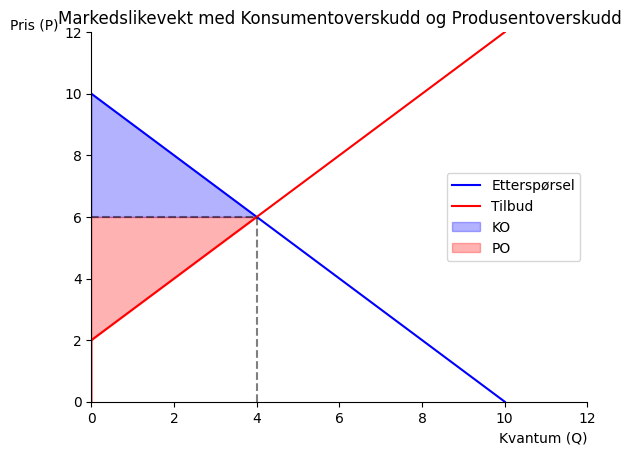

In [ ]:
def create_ax():
    fig, ax = plt.subplots()
    ax.set_ylabel('Pris (P)', loc='top', rotation=0)
    ax.set_xlabel('Kvantum (Q)', loc='right')
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    return fig, ax

P_num = np.linspace(0, 12, 200)
Q_e_fn = sp.lambdify(P, Demand_Q(P))
Q_t_fn = sp.lambdify(P, Supply_Q(P))

fig, ax = create_ax()
ax.plot(Q_e_fn(P_num), P_num, label='Etterspørsel', color='blue')
ax.plot(np.maximum(Q_t_fn(P_num), 0), P_num, label='Tilbud', color='red')

q_fill = np.linspace(0, float(Q_eq), 200)
inv_d_fn = sp.lambdify(Q, inv_demand)
inv_s_fn = sp.lambdify(Q, inv_supply)

ax.fill_between(q_fill, float(P_eq), inv_d_fn(q_fill), alpha=0.3, color='blue', label='KO')
ax.fill_between(q_fill, inv_s_fn(q_fill), float(P_eq), alpha=0.3, color='red', label='PO')
ax.hlines(float(P_eq), 0, float(Q_eq), color='black', linestyle='dashed', alpha=0.5)
ax.vlines(float(Q_eq), 0, float(P_eq), color='black', linestyle='dashed', alpha=0.5)
ax.set(xlim=(0, 12), ylim=(0, 12))
ax.legend()
ax.set_title('Markedslikevekt med Konsumentoverskudd og Produsentoverskudd')
plt.show()


Det samfunnsøkonomiske overskuddet kommer ved å legge sammen "PO" (Produsentoverskudd) og "KO" (Konsumentoverskuddet).

### Eksempel 2
Vi setter opp tilbud og etterspørsel, finner likevekten, og tegner likevekten i en figur. Dette er likevekt under frikonkurranse.

In [75]:
def demand(x):
    return (100 - x)
def supply(x):
    return 20 + x

In [76]:
x=sp.symbols('x', real=True, positive=True)
equ=sp.Eq(demand(x),supply(x))
equ

Eq(100 - x, x + 20)

In [77]:
x_eq=sp.solve(equ,x)
x_eq[0]

40

In [78]:
# Lagrer bare løsningen som et tall
x_eq=float(x_eq[0])
x_eq

40.0

In [79]:
p_eq=demand(x_eq)
p_eq

60.0

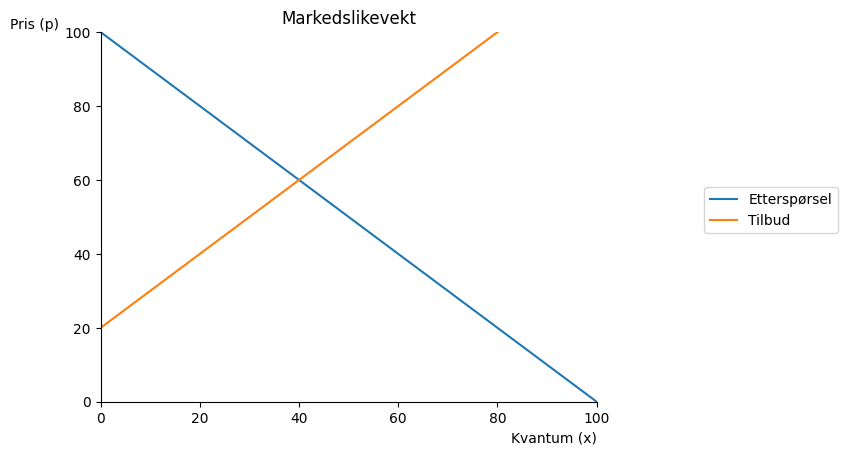

In [80]:
x_num=np.linspace(0.1,100,100)

#lag en akse

def create_ax():
                fig, ax = plt.subplots()
                ax.set_ylabel('Pris (p)', loc='top', rotation = 0)
                ax.set_xlabel('Kvantum (x)', loc='right')
                ax.set(xlim=(0,100))
                ax.set(ylim=(0,100))
                ax.spines['top'].set_color('none')
                ax.spines['right'].set_color('none')
                
                return fig, ax

fig, ax = create_ax()

# plott funksjonen

ax.plot(x_num, demand(x_num), label='Etterspørsel')
ax.plot(x_num, supply(x_num), label='Tilbud')



# tittel
ax.set_title('Markedslikevekt')

#vis navnene:
ax.legend(bbox_to_anchor=(1.5,0.6));

### Vi tegner inn likevektspris og -kvantum.

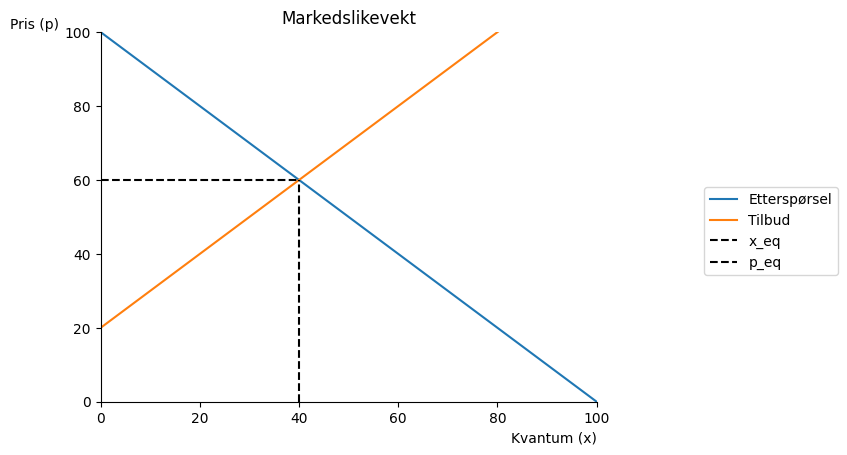

In [81]:
q = np.linspace(0,x_eq,100)

ax.vlines(x_eq,0,demand(x_eq), color='black',ls='dashed', label='x_eq')
ax.hlines(p_eq,0,x_eq, color='black',ls='dashed', label='p_eq')
ax.legend(bbox_to_anchor=(1.5,0.6))
fig


Den vertikale avstanden mellom etterspørselskurven og likevektsprisen er forskjellen i hva konsumenter er villig til å betale for hver ekstra enhet og hva de faktisk må betale. Dette er et overskudd til konsumenten, og kan summeres over alle enheter kjøpt. Dette gir oss konsumentoverskuddet som det grønne området nedenfor.

Den vertikale avstanden mellom likevektsprisen og tilbudskurven viser et overskudd for produsentene ettersom tilbudskurven angir deres grensekostnad. Det røde området i figuren nedenfor angir produsentoverskuddet. Både KO og PO er målt i pengeenheter, og summen utgjør samfunnsøkonomisk overskudd (SO = KO+PO).

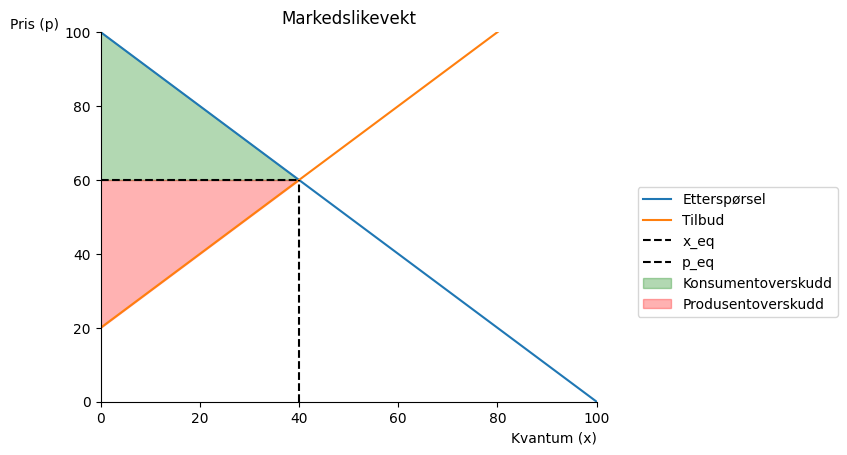

In [82]:
ax.fill_between(q,p_eq,demand(q), color = "green",alpha = 0.3,label='Konsumentoverskudd')
ax.fill_between(q,supply(q),p_eq, color = "red",alpha = 0.3,label='Produsentoverskudd')

ax.legend(bbox_to_anchor=(1.5,0.6))
fig

In [83]:
producer_surplus=sp.integrate(p_eq-supply(x),(x,0,x_eq))
producer_surplus

800.000000000000

In [84]:
consumer_surplus=sp.integrate(demand(x)-p_eq,(x,0,x_eq))
consumer_surplus


800.000000000000

In [85]:
welfare_surplus=float(sp.integrate(demand(x)-supply(x),(x,0,x_eq)))
welfare_surplus

1600.0

In [86]:
import pandas as pd

df = pd.DataFrame({
    'Overskudd': ['Solgt mengde', 'Pris', 'Konsumentoverskudd', 'Produsentoverskudd', 'Samfunnsøkonomisk overskudd'],
    'Verdi (kr)': [np.round(float(x_eq), 2), 
                   np.round(float(p_eq), 2), 
                   np.round(float(consumer_surplus), 2),
                   np.round(float(producer_surplus), 2),
                   np.round(float(welfare_surplus), 2)]
})

display(df)

,Overskudd,Verdi (kr)
0,Solgt mengde,40.0
1,Pris,60.0
2,Konsumentoverskudd,800.0
3,Produsentoverskudd,800.0
4,Samfunnsøkonomisk overskudd,1600.0


## Anbefalt lesestoff rundt norgespris for arbeidskravet

[https://finanspolitikkutvalget.no/2026/02/03/finanspolitikkutvalgets-uttalelse-for-2026/](https://finanspolitikkutvalget.no/2026/02/03/finanspolitikkutvalgets-uttalelse-for-2026/)

## 9.1 Krig på Kontinentet, høyere strømpriser og samfunnsøkonomisk overskudd


Conrad leser i avisen om krigen i Ukraina og at bortfallet av russisk gass har gjort at strømprisen på Kontinentet har gått opp. Han tenker at prisøkningen ikke kan være samfunnsøkonomisk effektivt.

Se for deg en situasjon hvor etterspørselen etter strøm er gitt ved:

$$Q^E = 1 - P$$

Mens tilbudet er gitt ved:

$$Q^T = -\gamma + P$$

Før krigen i Ukraina så var $\gamma_{fred} = 0$, men med stansen av gassleveransene fra Russland, får vi et skift i tilbudskurven, gitt ved $\gamma_{krig} = 0.2$.

**a.** Hva blir likevekten og det samfunnsøkonomiske overskuddet i dette markedet før krigen?




In [87]:
#

1/2

1/2

1/8

1/8

1/4

**b.** Hvordan påvirker krigen likevekten og det samfunnsøkonomiske overskuddet? Er du enig med Conrad at det har oppstått et effektivitetstap?


0.600000000000000

0.400000000000000

0.0800000000000000

0.0800000000000000

0.160000000000000

Effektivitetstap: 0.09


**c.** Conrad tenker at når krigen er over og vi igjen går tilbake til $\gamma_{fred} = 0$, så vil det samfunnsøkonomiske overskuddet øke, og med det også den samfunnsøkonomiske effektiviteten. Har han rett i det?




## 9.4 Hvorfor skal vi betale så mye for noe vi har så mye av?

Mange synes det er rart at prisen på bensin er så høy i et oljerikt land som Norge. Andre oljerike land har ofte veldig lave bensinpriser, hvorfor ikke også i Norge?

**a.** Begynn med frihandel, og vis ved hjelp av en figur *(dette er ikke en regneoppgave)* det samfunnsøkonomiske overskuddet i en situasjon hvor Norge eksporterer olje (tenk på olje og bensin som det samme).

**b.** Diskuter så konsekvensene av en lavprispolitikk, hvor vi ser for oss at myndighetene kontrollerer produksjon av olje og salget av bensin og hvor prisen i Norge settes lik grensekostnaden (i praksis lik autarkiprisen). Hva blir markedslikevekten, og hva er konsekvensene for konsumentoverskudd, produsentoverskudd og samfunnsøkonomisk effektivitet, sammenlignet med frihandels-scenariet i deloppgave a?



Her er det noen ekstra konsepter for de som er interesserte. 

[https://no.wikipedia.org/wiki/Baumol-effekten](https://no.wikipedia.org/wiki/Baumol-effekten)

[https://no.wikipedia.org/wiki/Hollandsk_syke](https://no.wikipedia.org/wiki/Hollandsk_syke)



## 9.5 Når den usynlige hånd svikter: Dødvektstapet ved forurensning. Frivillig oppgave

Se på figur 9.4 i hovedboken. Anta at etterspørselen er gitt ved $Q^E = 5 - P$ og tilbudet ved $Q^T = -1 + 2P$. Det er en miljøkostnad $m = 1.5$ per enhet produsert.

**a.** Hva er pris og mengde i markedslikevekten $a$ og den samfunnsøkonomisk optimale løsningen $b$?

**b.** Hvor stort er dødvektstapet $(\dagger)$ i markedslikevekten?
